# Data Validation

Validation of the first 500 days of 2026 Algothon price data (the research/train period). Checks the instrument universe, validates prices, calculates daily returns and highlights observations to investigate before modelling.

In [22]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option('display.float_format', '{:,.4f}'.format)

# Works whether Jupyter is started from the repository root or notebooks/
repo_root = Path.cwd()
if not (repo_root / 'backtester').exists():
    repo_root = repo_root.parent

data_dir = repo_root / 'backtester' / 'data' / '2026'
prices_path = data_dir / 'prices.txt'
tickers_path = data_dir / 'tickers.txt'

TRAIN_DAYS = 500
prices_full = pd.read_csv(prices_path, sep=r'\s+')
prices = prices_full.iloc[:TRAIN_DAYS].copy()
tickers = pd.read_csv(tickers_path, header=None, names=['ticker'])['ticker'].tolist()

assert len(prices_full) >= TRAIN_DAYS, 'Not enough observations for the train period'
assert prices.columns.tolist() == tickers, 'Price columns and tickers.txt do not match'
prices.shape

(750, 51)

## Instrument universe

Competition universe should contain 51 instruments: ALGO at index 0 and 50 non-ALGO stocks.

In [23]:
expected_n_instruments = 51
algo_index = 0

instrument_check = pd.DataFrame({
    'check': ['Number of instruments', 'Instrument 0'],
    'expected': [expected_n_instruments, 'ALGO'],
    'observed': [prices.shape[1], prices.columns[algo_index]],
})
instrument_check['passed'] = instrument_check['expected'] == instrument_check['observed']
display(instrument_check)

assert prices.shape[1] == expected_n_instruments
assert prices.columns[algo_index] == 'ALGO'

pd.DataFrame({'index': range(len(tickers)), 'ticker': tickers}).head(10)

,check,expected,observed,passed
0,Number of instruments,51,51,True
1,Instrument 0,ALGO,ALGO,True


,index,ticker
0,0,ALGO
1,1,AENO
2,2,LSST
3,3,SRNA
4,4,ELLT
5,5,AMRP
6,6,OTCS
7,7,HETT
8,8,HUXZ
9,9,DUCT


## Missing values and price ranges

In [24]:
validation = pd.DataFrame({
    'missing_values': prices.isna().sum(),
    'non_positive_prices': (prices <= 0).sum(),
    'min_price': prices.min(),
    'max_price': prices.max(),
    'first_price': prices.iloc[0],
    'last_price': prices.iloc[-1],
})
validation['price_range'] = validation['max_price'] - validation['min_price']
validation['total_return_pct'] = (validation['last_price'] / validation['first_price'] - 1) * 100

print(f'Days: {len(prices):,}')
print(f'Total missing values: {validation.missing_values.sum():,}')
print(f'Total non-positive prices: {validation.non_positive_prices.sum():,}')
display(validation.sort_values('total_return_pct'))

assert validation.missing_values.sum() == 0
assert validation.non_positive_prices.sum() == 0

Days: 750
Total missing values: 0
Total non-positive prices: 0


,missing_values,non_positive_prices,min_price,max_price,first_price,last_price,price_range,total_return_pct
SPLZ,0,0,27.9400,130.4000,104.3300,42.2000,102.4600,-59.5514
SRNA,0,0,48.8100,166.2600,134.2300,59.2100,117.4500,-55.8891
GARI,0,0,6.1300,17.4300,15.6000,7.2900,11.3000,-53.2692
HRND,0,0,6.0000,40.3900,24.0700,11.4900,34.3900,-52.2642
RTTH,0,0,16.7200,50.6900,39.8300,20.1100,33.9700,-49.5104
FARS,0,0,31.2500,66.4300,66.4300,33.8500,35.1800,-49.0441
NWIG,0,0,57.5000,151.7000,120.1900,64.1900,94.2000,-46.5929
BLBT,0,0,25.2600,56.1800,52.2300,28.1700,30.9200,-46.0655
HUXZ,0,0,42.4300,96.6000,83.6200,45.5800,54.1700,-45.4915
ALUT,0,0,8.2400,21.8800,17.4800,9.5800,13.6400,-45.1945


## Daily returns

Simple returns are used below: $r_t = P_t / P_{t-1} - 1$. The first row is undefined because there is no preceding price.

In [25]:
returns = prices.pct_change(fill_method=None)

return_summary = returns.agg(['mean', 'std', 'min', 'max']).T
return_summary['mean_pct'] = return_summary['mean'] * 100
return_summary['volatility_pct'] = return_summary['std'] * 100
return_summary[['mean_pct', 'volatility_pct', 'min', 'max']].sort_values('volatility_pct', ascending=False)

,mean_pct,volatility_pct,min,max
MMBT,0.2758,4.1313,-0.1237,0.1460
AETS,-0.0143,3.3574,-0.0867,0.1255
EELT,0.0748,3.3508,-0.1067,0.1149
RCRI,0.0168,3.3250,-0.0902,0.1047
NAYO,-0.0113,3.2578,-0.0901,0.1103
RTTH,-0.0392,3.2302,-0.0910,0.1124
CTGI,0.0533,3.0174,-0.0981,0.0858
ULXY,0.0702,2.9447,-0.0841,0.1128
HRND,-0.0555,2.9396,-0.0982,0.0854
AMRP,0.0322,2.7595,-0.0842,0.0876


## Daily-return distribution
Each bar counts how often a one-day return occurred across every instrument and day in the 500-day train sample.

Combines 499 daily returns × 51 instruments = 25,449 observations.


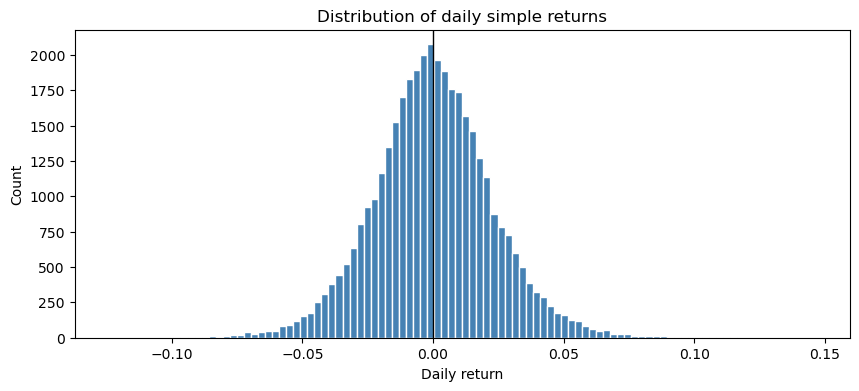

In [26]:
all_daily_returns = returns.to_numpy().ravel()
all_daily_returns = all_daily_returns[np.isfinite(all_daily_returns)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(all_daily_returns, bins=100, color='steelblue', edgecolor='white')
ax.set(title='Distribution of daily simple returns', xlabel='Daily return', ylabel='Count')
ax.axvline(0, color='black', linewidth=1)
plt.show()

**Notes / interpretation:** 
* Most returns should cluster near zero
* Long tails or isolated extreme moves should be checked

## Normalized price paths
Every instrument starts at 100, making their relative price changes directly comparable.

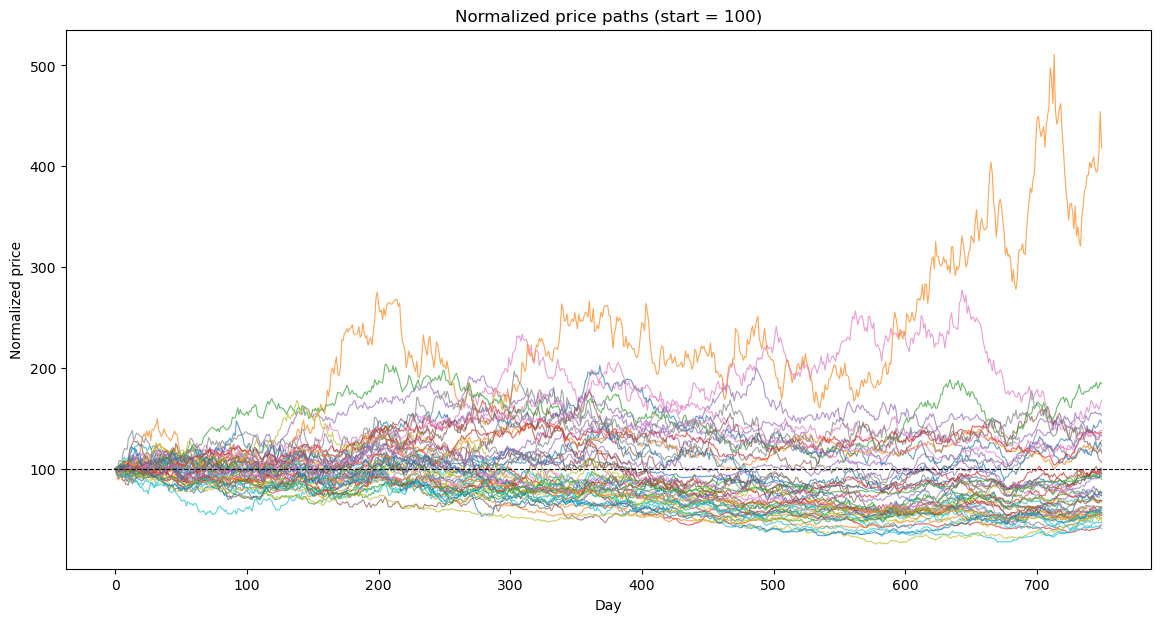

In [27]:
normalized_prices = prices.div(prices.iloc[0]).mul(100)

fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(normalized_prices.index, normalized_prices, linewidth=0.8, alpha=0.7)
ax.set(title='Normalized price paths (start = 100)', xlabel='Day', ylabel='Normalized price')
ax.axhline(100, color='black', linewidth=0.8, linestyle='--')
plt.show()

#### Five highest and five lowest ending normalized price levels

In [28]:
path_summary = pd.DataFrame({
    'ending_level': normalized_prices.iloc[-1],
    'minimum_level': normalized_prices.min(),
    'maximum_level': normalized_prices.max(),
})
path_summary['total_return_pct'] = path_summary['ending_level'] - 100

extreme_paths = pd.concat([
    path_summary.nlargest(5, 'ending_level'),
    path_summary.nsmallest(5, 'ending_level'),
])
display(extreme_paths.style.format('{:,.1f}'))

,ending_level,minimum_level,maximum_level,total_return_pct
MMBT,418.1,88.6,511.1,318.1
MDGI,184.1,92.1,203.4,84.1
OTCS,168.0,85.9,277.1,68.0
CUBO,152.6,86.1,156.3,52.6
SMAH,145.5,90.1,202.4,45.5
SPLZ,40.4,26.8,125.0,-59.6
SRNA,44.1,36.4,123.9,-55.9
GARI,46.7,39.3,111.7,-53.3
HRND,47.7,24.9,167.8,-52.3
RTTH,50.5,42.0,127.3,-49.5


**Notes / interpretation**

- Train-period price paths are highly dispersed: OTCS and MMBT finish near 215 and 208, while EAFC finishes near 40.
- MHRM, EAFC, and HRND each fall below 42 at some point, showing materially different price paths across instruments.

## Daily-return volatility by instrument
Higher bars indicate instruments with larger typical one-day price moves.

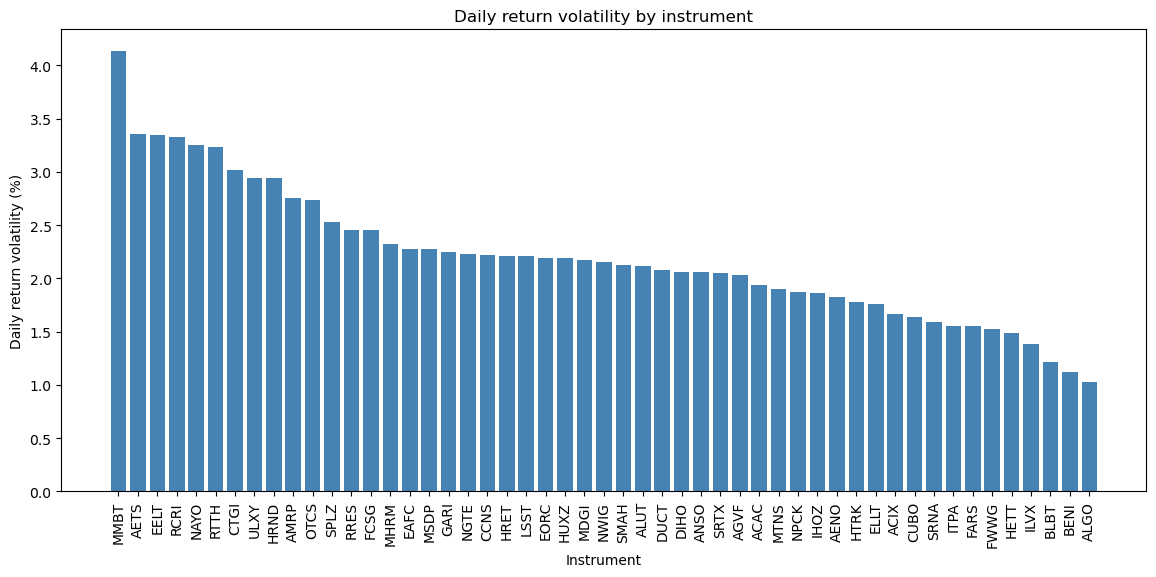

In [29]:
volatility_pct = returns.std().sort_values(ascending=False).mul(100)

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(volatility_pct.index, volatility_pct, color='steelblue')
ax.set(title='Daily return volatility by instrument', xlabel='Instrument', ylabel='Daily return volatility (%)')
ax.tick_params(axis='x', rotation=90)
plt.show()

#### Ten highest daily-return volatilities, plus ALGO

In [30]:
volatility_summary = volatility_pct.rename('daily_volatility_pct').to_frame()
top_volatility = pd.concat([
    volatility_summary.head(10),
    volatility_summary.loc[['ALGO']],
]).loc[lambda frame: ~frame.index.duplicated()]
display(top_volatility.style.format('{:.2f}%'))

,daily_volatility_pct
MMBT,4.13%
AETS,3.36%
EELT,3.35%
RCRI,3.32%
NAYO,3.26%
RTTH,3.23%
CTGI,3.02%
ULXY,2.94%
HRND,2.94%
AMRP,2.76%


**Notes / interpretation**

- MMBT has the largest train-period daily-return volatility (4.11%), followed by EELT (3.43%) and RCRI (3.37%).
- ALGO is comparatively low-volatility at 0.99%, so the highest bars are likely to drive a disproportionate share of portfolio risk and extreme-return observations.

## Extreme return observations

Identify the largest absolute one-day returns. These may reflect genuine market moves, regime changes or data-quality issues and should be investigated before modelling.

In [31]:
long_returns = (
    returns.rename_axis('day')
    .reset_index()
    .melt(id_vars='day', var_name='ticker', value_name='return')
    .dropna()
)

unusual_moves = (
    long_returns.assign(abs_return=lambda frame: frame['return'].abs())
    .nlargest(20, 'abs_return')
    .assign(return_pct=lambda frame: frame['return'] * 100)
    [['day', 'ticker', 'return_pct', 'abs_return']]
)
display(unusual_moves.style.format({'return_pct': '{:+.2f}%', 'abs_return': '{:.4f}'}))

,day,ticker,return_pct,abs_return
16221,471,MMBT,+14.60%,0.1460
15922,172,MMBT,+13.28%,0.1328
29355,105,AETS,+12.55%,0.1255
15816,66,MMBT,-12.37%,0.1237
16037,287,MMBT,+11.88%,0.1188
16063,313,MMBT,+11.50%,0.1150
28093,343,EELT,+11.49%,0.1149
16153,403,MMBT,+11.43%,0.1143
30092,92,ULXY,+11.28%,0.1128
13723,223,RTTH,+11.24%,0.1124


## Summary of findings

* The dataset is structurally valid
    * 500 train days, 51 instruments and ALGO correctly located at index 0
    * There are no missing or non-positive prices
* Stock price paths differ substantially across instruments: some rose strongly, while others declined sharply
    * OTCS ends at 215 (from 100), while EAFC ends at 40
* MMBT is the most volatile instrument (4.11% daily volatility) and produces several of the largest one-day moves
* ALGO is comparatively stable (0.99%).

### Next research

* Inspect the largest moves, especially in MMBT, to understand which instruments and periods drive the dataset’s highest volatility
* Test return relationships, autocorrelation, and correlations using rolling, time-respecting windows